# Build A Basic Chatbot With Langgraph(GRAPH API)

In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.1-8b-instant")

In [6]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(State)

#Adding node
graph_builder.add_node("llmchatbot", chatbot)

#Adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END )

#compile Graph
graph = graph_builder.compile()

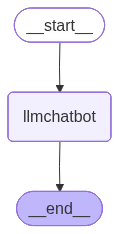

In [8]:
#Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages":"Hi"}) # type: ignore

In [10]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [11]:
for event in graph.stream({"messages":"Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm always ready to help and chat with you about anything that's on your mind. How about you? How's your day going so far?


## Chatbot With Tool

In [12]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'response_time': 0.64,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by [LangChain](https://www.ibm.com/think/topics/langchain), is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an [AI agent workflow](https://www.ibm.com/think/topics/ai-agents). The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the [AI workflow](https://www.ibm.com/think/topics/ai-workflow) as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this 

In [13]:
#Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """

    return a*b

In [14]:
tools =[tool, multiply]

In [15]:
llm_with_tool = llm.bind_tools(tools)

In [16]:
llm_with_tool

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001FFD45B0AD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001FFD45B1550>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input sho

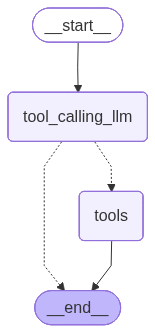

In [22]:
##StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

##Node Definition
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tool.invoke(state["messages"])]}

##Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)  # Add the function reference
builder.add_node("tools", ToolNode(tools))

##Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    
)

builder.add_edge("tools", END)

##Compile the graph
graph = builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
response = graph.invoke({"messages":"What is the most recent AI news"})

In [27]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the most recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (2zrjeysyy)
 Call ID: 2zrjeysyy
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/technology/x-probes-offensive-posts-by-xais-grok-chatbot-sky-news-reports-2026-03-08/", "title": "X probes offensive posts by xAI’s Grok chatbot, Sky News reports - Reuters", "score": 0.8479678, "published_date": "Sun, 08 Mar 2026 13:52:47 GMT", "content": "Skip to main content\n\n# X probes offensive posts by xAI’s Grok chatbot, Sky News reports\n\nBy Reuters\n\nMarch 8 (Reuters) - Social ​media platform ‌X is

In [32]:
response = graph.invoke({"messages":"What is 92 multiplied by 34 and then multiply 5"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 92 multiplied by 34 and then multiply 5
================================== Ai Message ==================================
Tool Calls:
  multiply (0seg2h499)
 Call ID: 0seg2h499
  Args:
    a: 92
    b: 34
================================= Tool Message =================================
Name: multiply

3128
